In [1]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [11]:
#load dataset
df=pd.read_csv('/content/loan.csv')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              61 non-null     int64 
 1   gender           61 non-null     object
 2   occupation       61 non-null     object
 3   education_level  61 non-null     object
 4   marital_status   61 non-null     object
 5   income           61 non-null     int64 
 6   credit_score     61 non-null     int64 
 7   loan_status      61 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


In [13]:
df.describe()

,age,income,credit_score
count,61.000000,61.000000,61.000000
mean,37.081967,78983.606557,709.836066
std,8.424755,33772.025802,72.674888
min,24.000000,25000.000000,560.000000
25%,30.000000,52000.000000,650.000000
50%,36.000000,78000.000000,720.000000
75%,43.000000,98000.000000,770.000000
max,55.000000,180000.000000,830.000000


In [16]:
df.shape

(61, 8)

In [17]:
df.isnull().sum()

,0
age,0
gender,0
occupation,0
education_level,0
marital_status,0
income,0
credit_score,0
loan_status,0


In [18]:
print("No.of records:",df.duplicated().sum())

No.of records: 0


In [19]:
#remove duplicate records
df.drop_duplicates(inplace=True)

In [20]:
df.shape

(61, 8)

In [21]:
#idetify null values
df.isnull().sum()

,0
age,0
gender,0
occupation,0
education_level,0
marital_status,0
income,0
credit_score,0
loan_status,0


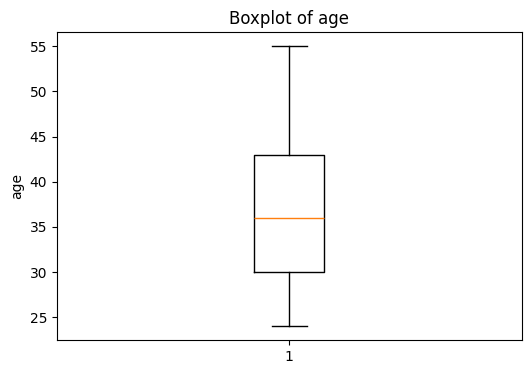

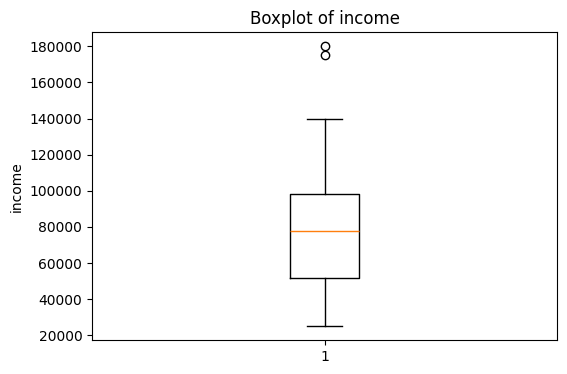

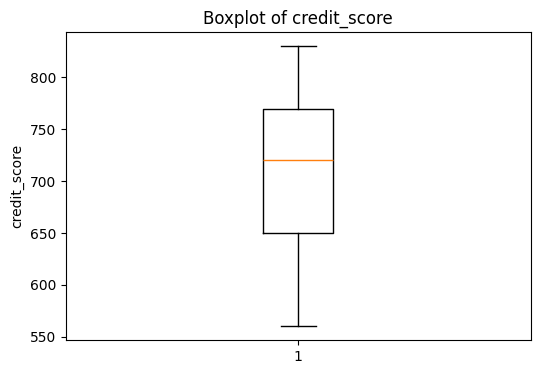

In [26]:
import matplotlib.pyplot as plt

num_cols = ['age', 'income', 'credit_score']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title("Boxplot of " + col)
    plt.ylabel(col)
    plt.show()

In [28]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (59, 8)


In [29]:
df.shape

(59, 8)

<Axes: ylabel='income'>

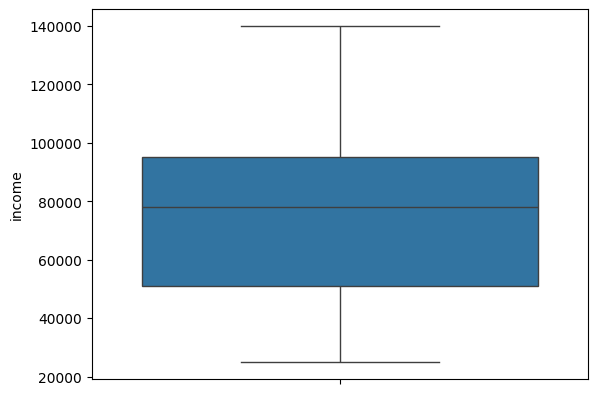

In [30]:
#outliers in sepal width
sns.boxplot(df['income'])

In [31]:
print(df['loan_status'].unique())

['Approved' 'Denied']


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['loan_status'] = le.fit_transform(df['loan_status'])

print(df['loan_status'].unique())

[0 1]


In [38]:
# Separate features (x) and target (y)
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Identify categorical columns for one-hot encoding
categorical_cols = ['gender', 'occupation', 'education_level', 'marital_status']

# Apply one-hot encoding to categorical columns in x
x = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

In [39]:
#split the data into training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=15)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(x_train)

print(X_scaled)

[[ 0.08364338  0.1242753   0.24045194 ... -0.30499714 -0.58554004
  -0.71842121]
 [ 1.73222733  0.96391032  1.02526036 ... -0.30499714 -0.58554004
  -0.71842121]
 [ 0.71771413  0.59885161  0.71133699 ... -0.30499714 -0.58554004
  -0.71842121]
 ...
 [ 0.21045753 -0.02174818  0.24045194 ... -0.30499714 -0.58554004
  -0.71842121]
 [ 1.60541318  1.51149837  1.4961454  ... -0.30499714 -0.58554004
  -0.71842121]
 [-0.04317077  0.489334    0.55437531 ... -0.30499714  1.70782513
  -0.71842121]]


In [41]:
# Model Building

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train, y_train)

KNeighborsClassifier()

In [42]:
# predictions on test data

y_pred = knn.predict(x_test)

print(y_pred)

[0 0 1 0 1 1 1 0 1 0 1 0]


In [43]:
# Evaluation Metrics

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12


Confusion Matrix:
[[6 0]
 [0 6]]


In [44]:
# evaluation metrics

accuracy_score(y_test, y_pred)

classification_report(y_test, y_pred)

confusion_matrix(y_test, y_pred)

array([[6, 0],
       [0, 6]])

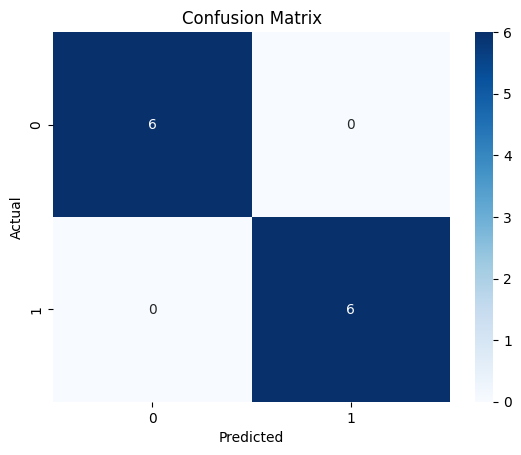

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<Axes: >

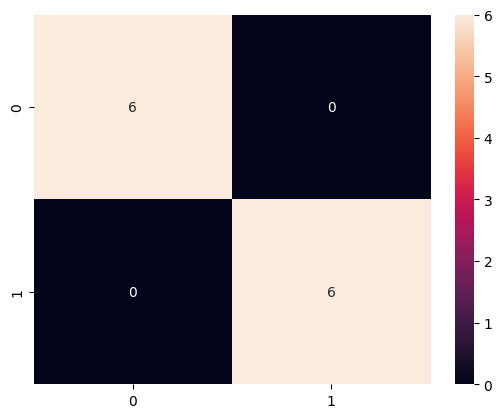

In [46]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)

In [49]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Predictions on test data
y_pred = knn.predict(x_test)

# Probability predictions
y_proba = knn.predict_proba(x_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(
    y_test,
    y_proba[:, 1], # Use probabilities of the positive class
    multi_class='ovr'
)

print("ROC-AUC Score:", roc_auc)

Accuracy: 1.0
ROC-AUC Score: 1.0


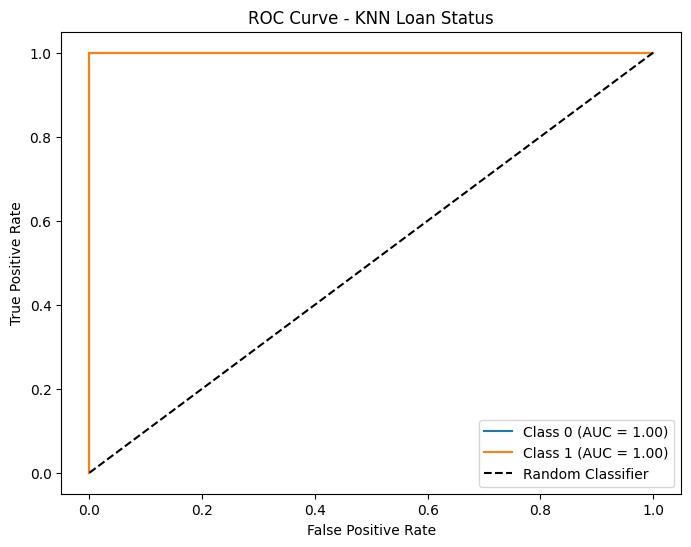

In [55]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.unique

# Predict probabilities
y_proba = knn.predict_proba(x_test)

# Determine the actual number of classes from y_test
unique_classes = np.unique(y_test)
n_classes = len(unique_classes)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(n_classes): # Iterate over the actual number of classes
    # Create binary y_true for the current class (one-vs-rest)
    y_true_class_i = (y_test == unique_classes[i]).astype(int)
    y_score_class_i = y_proba[:, i]

    fpr, tpr, _ = roc_curve(y_true_class_i, y_score_class_i)
    auc_score = roc_auc_score(y_true_class_i, y_score_class_i)

    plt.plot(
        fpr, tpr,
        label=f'Class {unique_classes[i]} (AUC = {auc_score:.2f})'
    )

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Loan Status') # Changed title to reflect dataset
plt.legend()
#plt.grid()
plt.show()